# 3.3. Нагрузки и опоры

## Truss.apply_load()

`apply_load(*args)`

Метод прикладывает нагрузку к указанному узлу.

**Аргументы:**

- `(location, magnitude, direction)` — кортеж, где:
  - `location` — метка узла, к которому применяется нагрузка.
  - `magnitude` — величина нагрузки (должна быть положительной).
  - `direction` — угол направления нагрузки (в градусах, против часовой стрелки от горизонтали).

### Пример

{'A': [[P, 90], [P/2, 45], [P/4, 90]]}


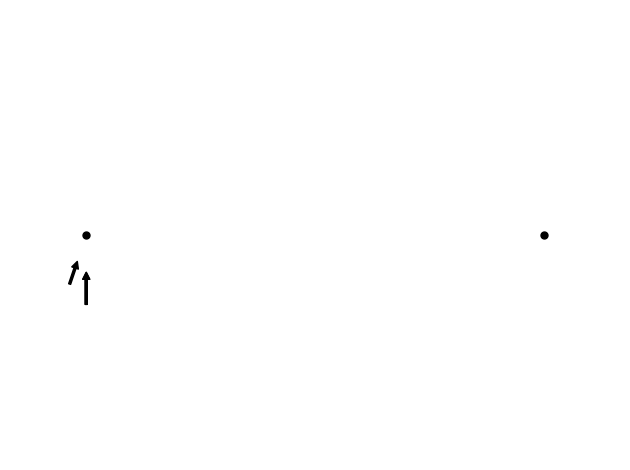

In [8]:
from sympy.physics.continuum_mechanics.truss import Truss
from sympy import symbols

t = Truss()
t.add_node(("A", 0, 0), ("B", 3, 0))
P = symbols("P")
t.apply_load(("A", P, 90), ("A", P/2, 45), ("A", P/4, 90))
print(t.loads)  # {"A": [[P, 90], [P/2, 45], [P/4, 90]]}
p = t.draw()
p.xlim = (-0.5, 3.5)
p.ylim = (-0.5, 0.5)
p.show()

## Truss.apply_support()

`apply_support(*args)`

Метод добавляет опоры (шарнирные или роликовые) к указанным узлам.

**Аргументы:**

- `(location, type)` — кортеж, где:
  - `location` — метка узла, к которому добавляется опора.
  - `type` — тип опоры (`pinned` или `roller`).

### Пример

{'A': 'pinned', 'B': 'roller'}


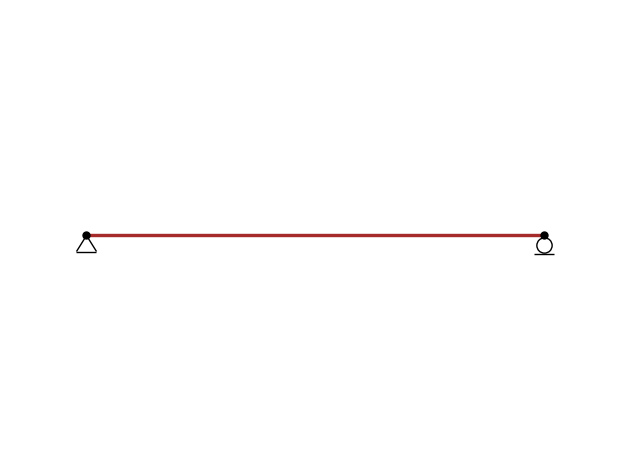

In [18]:
from sympy.physics.continuum_mechanics.truss import Truss

t = Truss()
t.add_node(("A", 0, 0), ("B", 3, 0))
t.add_member(('AB', 'A', 'B'))
t.apply_support(("A", "pinned"), ("B", "roller"))
print(t.supports)  # {"A": "pinned", "B": "roller"}
p = t.draw()
p.xlim = (-0.5, 3.5)
p.ylim = (-1.5, 1.5)
p.show()

## Truss.remove_load()

`remove_load(*args)`

Этот метод удаляет существующую внешнюю нагрузку (нагрузки) в указанном узле (узлах).

**Аргументы:**

**Входными данными этого метода являются кортежи вида (location, magnitude, direction).**

**location: String или Symbol**

> Метка узла, в котором приложена и подлежит удалению нагрузка.

**magnitude: Sympifyable**

> Величина приложенной нагрузки.

**direction: Sympifyable**

> Угол в градусах, который вектор нагрузки составляет с горизонталью в направлении против часовой стрелки. Принимает значения от 0 до 360 включительно.

### Пример

{'A': [[P, 90], [P/2, 45], [P/4, 90]]}


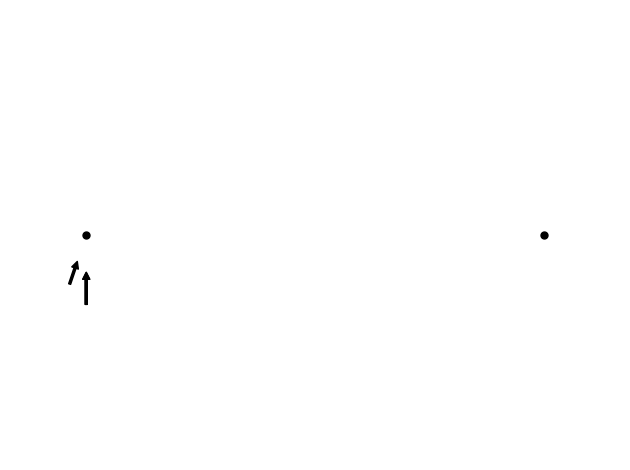

In [5]:
from sympy.physics.continuum_mechanics.truss import Truss
from sympy import symbols
t = Truss()
t.add_node(('A', 0, 0), ('B', 3, 0))
P = symbols('P')
t.apply_load(('A', P, 90), ('A', P/2, 45), ('A', P/4, 90))
print(t.loads)
p = t.draw()
p.xlim = (-0.5, 3.5)
p.ylim = (-0.5, 0.5)
p.show()

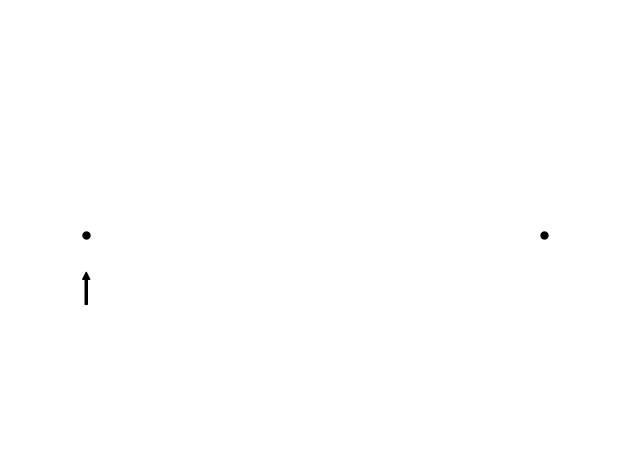

In [6]:
t.remove_load(('A', P/4, 90), ('A', P/2, 45))
t.loads
p = t.draw()
p.xlim = (-0.5, 3.5)
p.ylim = (-0.5, 0.5)
p.show()

## Truss.remove_support(*args)

`remove-support(*args)`

Этот метод удаляет опору из указанного узла (узлов).

**Аргументы:**

**locations: String или Symbol**

> Метка узла (узлов), в котором необходимо удалить опору.

### Пример

{'A': 'pinned', 'B': 'roller'}


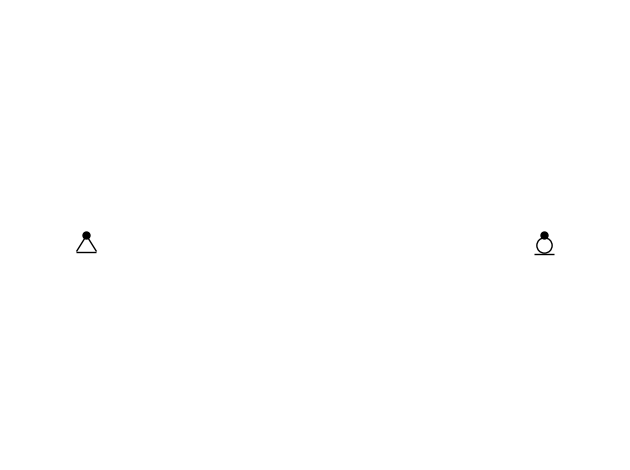

In [12]:
from sympy.physics.continuum_mechanics.truss import Truss
t = Truss()
t.add_node(('A', 0, 0), ('B', 3, 0))
t.apply_support(('A', 'pinned'), ('B', 'roller'))
print(t.supports)
p = t.draw()
p.xlim = (-0.5, 3.5)
p.ylim = (-1.5, 1.5)
p.show()

{}


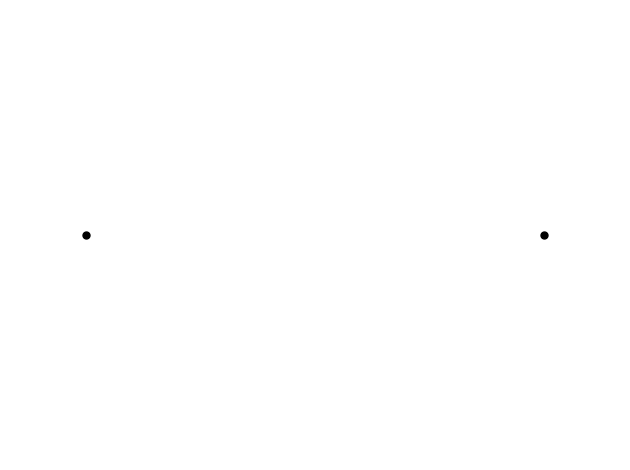

In [9]:
t.remove_support('A','B')
print(t.supports)
p = t.draw()
p.xlim = (-0.5, 3.5)
p.ylim = (-0.5, 0.5)
p.show()

## Truss.loads

`property loads`

Возвращает нагрузки, приложенные к ферме.

## Truss.supports

`property supports`

Возвращает узлы с заданными опорами, а также тип опоры (шарнирно-неподвижная или шарнирно-подвижная).